# Kurek Aleksander 3ID15B - ABD projekt

## Temat projektu:
###    Analiza powodów decyzji banku dotyczącej udzielenia kredytu mieszkaniowego na podstawie danych “Loan-Approval-Prediction-Dataset”.

## Źródło danych projektu: Dane dostępne są na platformie kaggle.com pod linkiem:
    https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset/data

## Charakterystyka zbioru danych:
### Liczba rekordów: 4269,
### Lista atrybutów: 13
    - loan_id: ID wniosku kredytowego - nie będzie używany,
    - no_of_dependents: Liczba osób na utrzymaniu <numeryczny>,
    - education: Wykształcenie wyższe (Graduate/Not Graduate) - <1/ 0>,
    - self_employed: Samozatrudnienie (Yes/No) - <1/ 0>,
    - income_annum: Roczny dochód pożyczkobiorcy <numeryczny w tysiącach>,
    - loan_amount: Kwota pożyczki <numeryczny w tysiącach>,
    - loan_term: Okres pożyczki w miesiącach <numeryczny>,
    - cibil_score: Ocena kredytowa pożyczkobiorcy <numeryczny> (współczynnik ten jest wykorzystywany w Indiach, więc można zakładać, że dane te pochodzą z tamtego kraju),
    - residential_assets_value: Wartość mieszkań pożyczkobiorcy <numeryczny w tysiącach>,
    - commercial_assets_value: Wartość innych nieruchomości pożyczkobiorcy <numeryczny w tysiącach>,
    - luxury_assets_value: Wartość luksusowych artykułów pożyczkobiorcy <numeryczny w tysiącach>,
    - bank_asset_value: Wartość aktywów pożyczkobiorcy w bankach <numeryczny w tysiącach>,
    - loan_status: Status kredytu (Approved/ Rejected) - <1/ 0>,

<b>Użyte metody:</b>
   - Czyszczenie i eksploracja danych,
   - Korelacja,
   - Podział binarny,
   - Drzewo decyzyjnr,

# Przygotowanie danych do analizy i ich czyszczenie

In [1]:
import pandas as pd

df = pd.read_csv('./data/loan_approval_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


<b>Zbiór danych nie zawiera pustych wartości.

In [2]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<b>Kolumna 'loan_id' jest zbędna.

In [3]:
df.drop(columns=['loan_id'], inplace=True)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<b>Sprawdźmy jakie unikalne wartości są w kolumnach z danymi symbolicznymi w celu konwersji na dane numeryczne.

In [4]:
def map_values(value, value_map):
    return value_map.get(value, value)

for column in [' education', ' self_employed', ' loan_status']:
    unique_values = df[column].unique()
    print(f"Unique values for {column}: {unique_values}")

Unique values for  education: [' Graduate' ' Not Graduate']
Unique values for  self_employed: [' No' ' Yes']
Unique values for  loan_status: [' Approved' ' Rejected']


<b>Zamienimy wartości atrybutów symbolicznych na numeryczne.

In [5]:
education_map = {' Graduate': 1, ' Not Graduate': 0}
self_employed_map = {' Yes': 1, ' No': 0}
loan_status_map = {' Approved': 1, ' Rejected': 0}

df[' education'] = df[' education'].map(lambda x: map_values(x, education_map))
df[' self_employed'] = df[' self_employed'].map(lambda x: map_values(x, self_employed_map))
df[' loan_status'] = df[' loan_status'].map(lambda x: map_values(x, loan_status_map))

<b>Sprawdźmy rezultat zamiany.

In [6]:
for column in [' education', ' self_employed', ' loan_status']:
    unique_values = df[column].unique()
    print(f"Unique values for {column}: {unique_values}")

Unique values for  education: [1 0]
Unique values for  self_employed: [0 1]
Unique values for  loan_status: [1 0]


In [7]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


<b>Niektóre wartości liczbowe wydają się duże, sprawdźmy je w celu zmniejszenia wielkości liczb.

In [8]:
for column in df.columns:
    min_val = df[column].min()
    max_val = df[column].max()
    print(f"Column: {column}, Minimum: {min_val}, Maximum: {max_val}")

Column:  no_of_dependents, Minimum: 0, Maximum: 5
Column:  education, Minimum: 0, Maximum: 1
Column:  self_employed, Minimum: 0, Maximum: 1
Column:  income_annum, Minimum: 200000, Maximum: 9900000
Column:  loan_amount, Minimum: 300000, Maximum: 39500000
Column:  loan_term, Minimum: 2, Maximum: 20
Column:  cibil_score, Minimum: 300, Maximum: 900
Column:  residential_assets_value, Minimum: -100000, Maximum: 29100000
Column:  commercial_assets_value, Minimum: 0, Maximum: 19400000
Column:  luxury_assets_value, Minimum: 300000, Maximum: 39200000
Column:  bank_asset_value, Minimum: 0, Maximum: 14700000
Column:  loan_status, Minimum: 0, Maximum: 1


<b>Zamiana wartości kolumn z dużymi liczbami na tysiące.

In [9]:
columns_to_convert = [' income_annum', ' loan_amount', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']
for column in columns_to_convert:
    df[column] = (df[column] / 1000).astype(int)

for column in df.columns:
    min_val = df[column].min()
    max_val = df[column].max()
    print(f"Column: {column}, Minimum: {min_val}, Maximum: {max_val}")

Column:  no_of_dependents, Minimum: 0, Maximum: 5
Column:  education, Minimum: 0, Maximum: 1
Column:  self_employed, Minimum: 0, Maximum: 1
Column:  income_annum, Minimum: 200, Maximum: 9900
Column:  loan_amount, Minimum: 300, Maximum: 39500
Column:  loan_term, Minimum: 2, Maximum: 20
Column:  cibil_score, Minimum: 300, Maximum: 900
Column:  residential_assets_value, Minimum: -100, Maximum: 29100
Column:  commercial_assets_value, Minimum: 0, Maximum: 19400
Column:  luxury_assets_value, Minimum: 300, Maximum: 39200
Column:  bank_asset_value, Minimum: 0, Maximum: 14700
Column:  loan_status, Minimum: 0, Maximum: 1


<b>Zmiana nazw kolumn w celu usunięcia zbędnej spacji.

In [10]:
new_column_names = {
    ' no_of_dependents': 'No_of_dependents',
    ' education': 'Education',
    ' self_employed': 'Self_employed',
    ' income_annum': 'Income_annum_in_k',
    ' loan_amount': 'Loan_amount_in_k',
    ' loan_term': 'Loan_term',
    ' cibil_score': 'Cibil_score',
    ' residential_assets_value': 'Residential_assets_value_in_k',
    ' commercial_assets_value': 'Commercial_assets_value_in_k',
    ' luxury_assets_value': 'Luxury_assets_value_in_k',
    ' bank_asset_value': 'Bank_asset_value_in_k',
    ' loan_status': 'Loan_status'
}

df.rename(columns=new_column_names, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   No_of_dependents               4269 non-null   int64
 1   Education                      4269 non-null   int64
 2   Self_employed                  4269 non-null   int64
 3   Income_annum_in_k              4269 non-null   int32
 4   Loan_amount_in_k               4269 non-null   int32
 5   Loan_term                      4269 non-null   int64
 6   Cibil_score                    4269 non-null   int64
 7   Residential_assets_value_in_k  4269 non-null   int32
 8   Commercial_assets_value_in_k   4269 non-null   int32
 9   Luxury_assets_value_in_k       4269 non-null   int32
 10  Bank_asset_value_in_k          4269 non-null   int32
 11  Loan_status                    4269 non-null   int64
dtypes: int32(6), int64(6)
memory usage: 300.3 KB


<b>Zapisanie wyczyszczonego pliku csv.

In [12]:
df_clean = df

df.to_csv('./data/loan_approval_dataset_mod.csv', index=False)

# Wstępna analiza danych

In [13]:
df_clean.head()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
0,2,1,0,9600,29900,12,778,2400,17600,22700,8000,1
1,0,0,1,4100,12200,8,417,2700,2200,8800,3300,0
2,3,1,0,9100,29700,20,506,7100,4500,33300,12800,0
3,3,1,0,8200,30700,8,467,18200,3300,23300,7900,0
4,5,0,1,9800,24200,20,382,12400,8200,29400,5000,0


<b>Sprawdźmy jakie unikalne wartości są w kolumnach z danymi symbolicznymi i ilości tych wartości.

In [14]:
columns = ['No_of_dependents', 'Education',	'Self_employed', 'Loan_term', 'Loan_status']

for column in columns:
    value = df_clean[column].value_counts(ascending=True)
    print(f"Column: {column} {value}\n Sum: {value.sum()}\n")

Column: No_of_dependents No_of_dependents
5    673
1    697
2    708
0    712
3    727
4    752
Name: count, dtype: int64
 Sum: 4269

Column: Education Education
0    2125
1    2144
Name: count, dtype: int64
 Sum: 4269

Column: Self_employed Self_employed
0    2119
1    2150
Name: count, dtype: int64
 Sum: 4269

Column: Loan_term Loan_term
8     386
2     404
14    405
20    411
16    412
18    422
10    436
4     447
12    456
6     490
Name: count, dtype: int64
 Sum: 4269

Column: Loan_status Loan_status
0    1613
1    2656
Name: count, dtype: int64
 Sum: 4269



<b>Stwórzmy wykresy, aby lepiej zrozumieć dane.

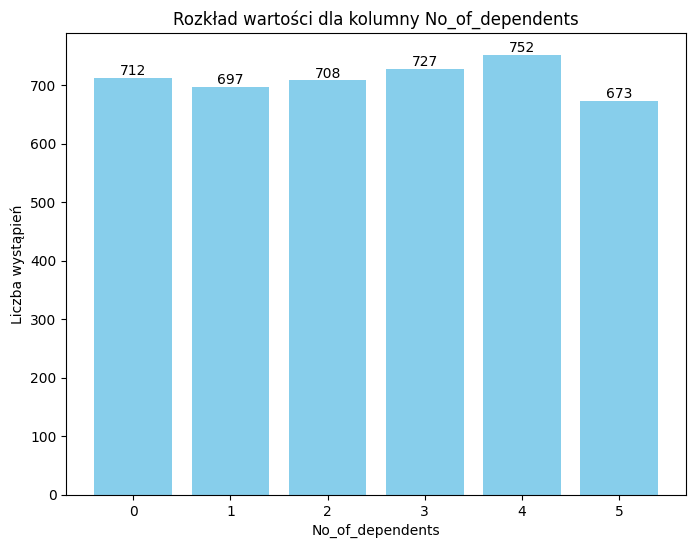

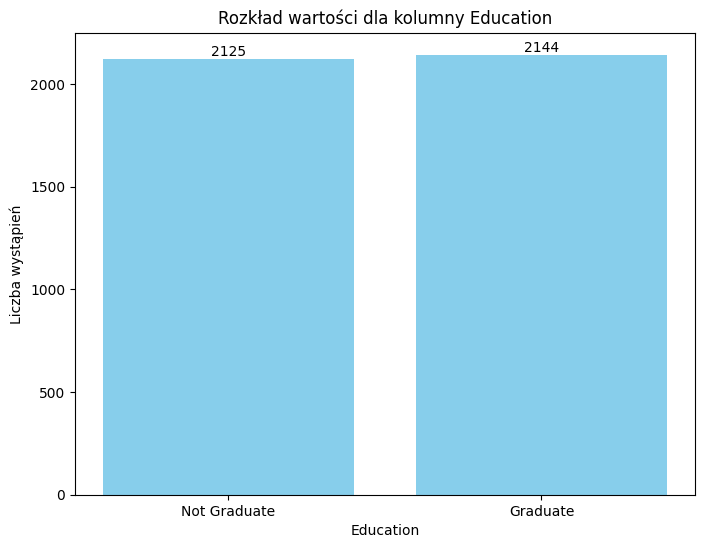

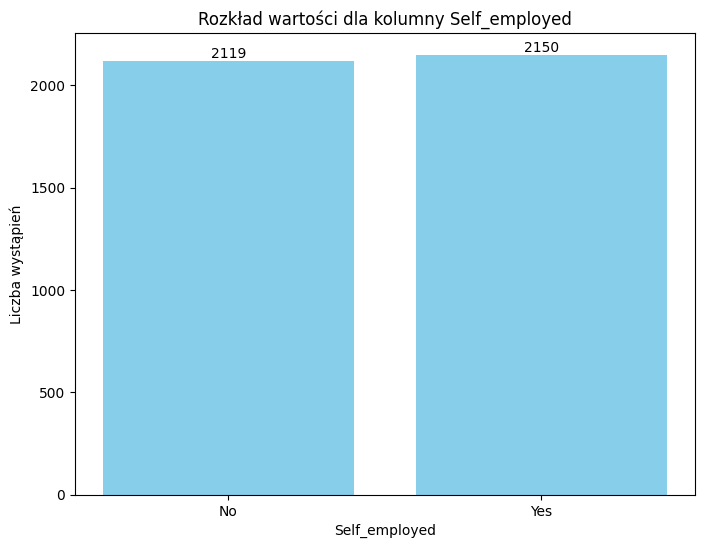

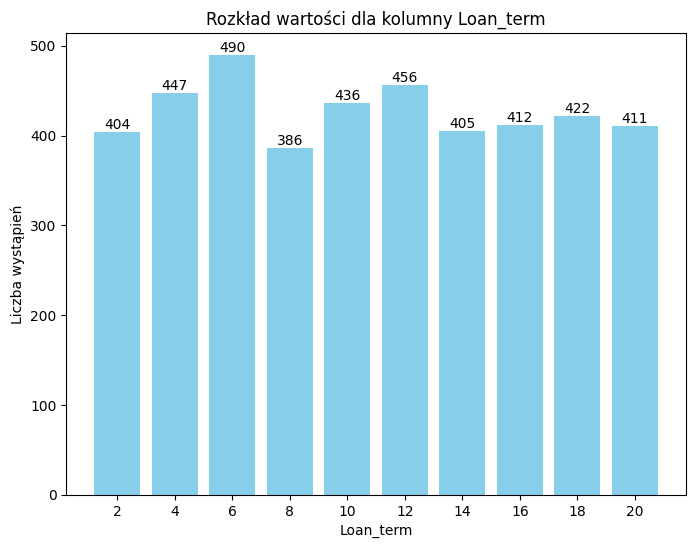

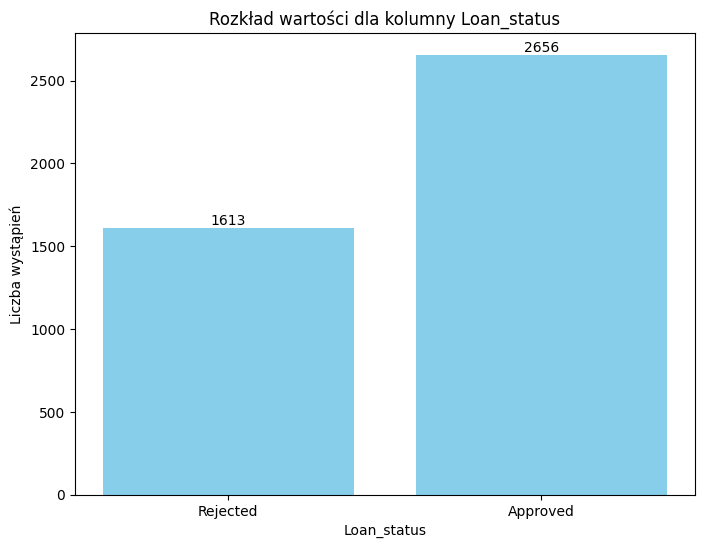

In [15]:
import matplotlib.pyplot as plt

education_map_reverse = {1: 'Graduate', 0: 'Not Graduate'}
self_employed_map_reverse = {1: 'Yes', 0: 'No'}
loan_status_map_reverse = {1: 'Approved', 0: 'Rejected'}

columns = ['No_of_dependents', 'Education', 'Self_employed', 'Loan_term', 'Loan_status']

for column in columns:
    value_counts = df_clean[column].value_counts(ascending=True)
    value_counts_sorted = value_counts.sort_index()

    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(value_counts_sorted)), value_counts_sorted.values, color='skyblue')

    for i, bar in enumerate(bars):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', va='bottom', ha='center')

    if column == 'Education':
        plt.xticks(range(len(value_counts_sorted)), [education_map_reverse[idx] for idx in value_counts_sorted.index])
    elif column == 'Self_employed':
        plt.xticks(range(len(value_counts_sorted)), [self_employed_map_reverse[idx] for idx in value_counts_sorted.index])
    elif column == 'Loan_status':
        plt.xticks(range(len(value_counts_sorted)), [loan_status_map_reverse[idx] for idx in value_counts_sorted.index])
    else:
        plt.xticks(range(len(value_counts_sorted)), value_counts_sorted.index)

    plt.xlabel(column)
    plt.ylabel('Liczba wystąpień')
    plt.title(f'Rozkład wartości dla kolumny {column}')
    plt.show()

<b><font color='red'>Wartości rozłożone są w miarę równomiernie, tylko liczba Pozytywnych decyzji jest większa od Negatywnych, co nie pozwala nam określić wstępnych założeń podziału zbioru.

## Korelacja i podział binarny

In [16]:
columns = ['Income_annum_in_k',	'Loan_amount_in_k', 'Cibil_score', 'Residential_assets_value_in_k', 'Commercial_assets_value_in_k', 'Luxury_assets_value_in_k', 'Bank_asset_value_in_k']

df_clean[columns].describe()

,Income_annum_in_k,Loan_amount_in_k,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k
count,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000
mean,5059.123917,15133.450457,599.936051,7472.616538,4973.155306,15126.305926,4976.692434
std,2806.839832,9043.362985,172.430401,6503.636588,4388.966090,9103.753665,3250.185306
min,200.000000,300.000000,300.000000,-100.000000,0.000000,300.000000,0.000000
25%,2700.000000,7700.000000,453.000000,2200.000000,1300.000000,7500.000000,2300.000000
50%,5100.000000,14500.000000,600.000000,5600.000000,3700.000000,14600.000000,4600.000000
75%,7500.000000,21500.000000,748.000000,11300.000000,7600.000000,21700.000000,7100.000000
max,9900.000000,39500.000000,900.000000,29100.000000,19400.000000,39200.000000,14700.000000


In [17]:
df_clean.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
No_of_dependents,1.000000,0.002697,0.000765,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,-0.018114
Education,0.002697,1.000000,-0.023224,0.011625,0.010631,-0.008417,-0.004649,0.010930,-0.006763,0.012471,0.009424,0.004918
Self_employed,0.000765,-0.023224,1.000000,0.002368,0.001450,0.004107,-0.004866,0.006144,-0.017998,0.004413,-0.000215,0.000345
Income_annum_in_k,0.007266,0.011625,0.002368,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,-0.015189
Loan_amount_in_k,-0.003366,0.010631,0.001450,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,0.016150
Loan_term,-0.020111,-0.008417,0.004107,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,-0.113036
Cibil_score,-0.009998,-0.004649,-0.004866,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,0.770518
Residential_assets_value_in_k,0.007376,0.010930,0.006144,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,-0.014367
Commercial_assets_value_in_k,-0.001531,-0.006763,-0.017998,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,0.008246
Luxury_assets_value_in_k,0.002817,0.012471,0.004413,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517,-0.015465


<b>Można zauważyć, że atrybut 'Cibil_score' ma współczynnik korelacji dodatni 0.77 co świadczy, że spośród innych atrybutów ma najwyższy wpływ na decyzję banku.

<b>Określmy wartości skali Cibila dla jakiej bank zgodzi się na kredyt.

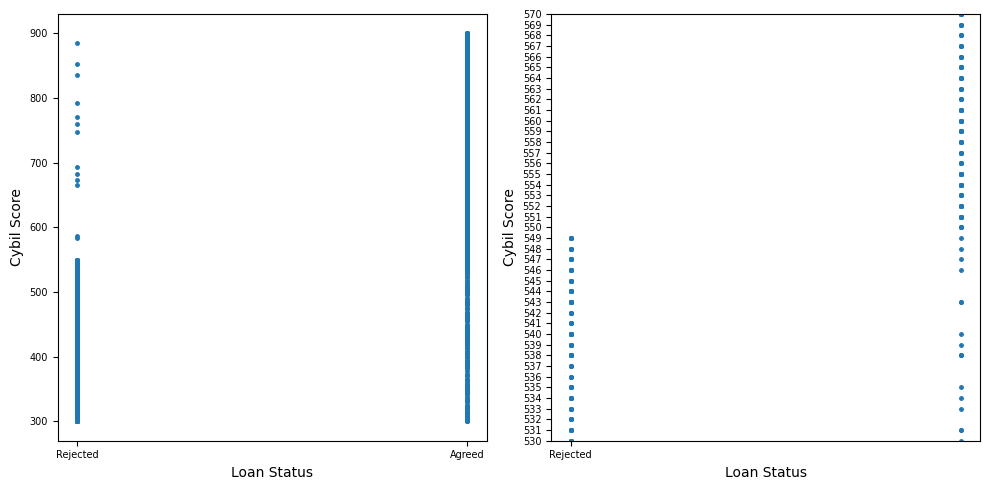

In [18]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

y = df_clean['Cibil_score']
x = df_clean['Loan_status']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(x, y, '.', markersize=5)
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['Rejected', 'Agreed'], fontsize=7)
axs[0].set_ylabel('Cybil Score', fontsize=10)
axs[0].set_xlabel('Loan Status', fontsize=10)
axs[0].tick_params(axis='both', which='both', labelsize=7)

axs[1].plot(x, y, '.', markersize=5)
axs[1].set_xticks([0])
axs[1].set_xticklabels(['Rejected'], fontsize=7)
axs[1].set_ylabel('Cybil Score', fontsize=10)
axs[1].set_xlabel('Loan Status', fontsize=10)
axs[1].tick_params(axis='both', which='both', labelsize=7)
axs[1].set_ylim(530, 570)
axs[1].set_yticks(np.arange(530, 571, 1))

plt.tight_layout()
plt.show()

<b>Podzielenie zbioru na dwie części pod względem wartości atrybutu 'Cibil_score' 549

In [19]:
df_cib_h = df_clean.loc[df_clean['Cibil_score'] >= 549]

df_cib_l = df_clean.loc[df_clean['Cibil_score'] < 549]

<b>Sprawdzenie korelacji pomiędzy atrybutami, gdzie 'Cibil score' jest większy bądź równy 549

In [20]:
df_cib_h.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
No_of_dependents,1.000000,-0.028891,0.004459,-0.002831,-0.017149,-0.020688,0.035241,0.010061,-0.013381,-0.000451,0.008877,0.045622
Education,-0.028891,1.000000,-0.021755,-0.016867,-0.012070,-0.012940,-0.030744,-0.000828,-0.005785,-0.010128,-0.022457,-0.008057
Self_employed,0.004459,-0.021755,1.000000,-0.013461,-0.012650,0.020554,-0.002754,-0.010135,-0.037266,-0.013429,-0.021453,0.009717
Income_annum_in_k,-0.002831,-0.016867,-0.013461,1.000000,0.930048,0.032144,-0.037649,0.630665,0.654507,0.928988,0.855837,0.020178
Loan_amount_in_k,-0.017149,-0.012070,-0.012650,0.930048,1.000000,0.027439,-0.044273,0.587122,0.618510,0.863731,0.798691,0.008452
Loan_term,-0.020688,-0.012940,0.020554,0.032144,0.027439,1.000000,-0.004260,0.025008,0.026788,0.035021,0.038238,-0.008741
Cibil_score,0.035241,-0.030744,-0.002754,-0.037649,-0.044273,-0.004260,1.000000,-0.000954,-0.005119,-0.047455,-0.029194,0.049608
Residential_assets_value_in_k,0.010061,-0.000828,-0.010135,0.630665,0.587122,0.025008,-0.000954,1.000000,0.422899,0.585786,0.526930,0.024327
Commercial_assets_value_in_k,-0.013381,-0.005785,-0.037266,0.654507,0.618510,0.026788,-0.005119,0.422899,1.000000,0.599734,0.574469,0.038102
Luxury_assets_value_in_k,-0.000451,-0.010128,-0.013429,0.928988,0.863731,0.035021,-0.047455,0.585786,0.599734,1.000000,0.785419,0.029060


<b>Żaden atrybut nie posiada silnej korelacji z 'Loan_status' ani 'Cibil_score'. Wiec nie możemy określić powodu zmiany decyzji banku ani wpływu innych atrybutów na skalę Cibila.

<b>Sprawdzenie korelacji pomiędzy atrybutami, gdzie 'Cibil score' jest mniejszy od 549

In [21]:
df_cib_l.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
No_of_dependents,1.000000,0.047383,-0.004344,0.020785,0.016123,-0.018718,0.009177,0.002274,0.014845,0.006367,0.014179,0.007628
Education,0.047383,1.000000,-0.025300,0.052465,0.043382,-0.002189,-0.001269,0.027877,-0.008118,0.044764,0.055076,-0.002355
Self_employed,-0.004344,-0.025300,1.000000,0.024963,0.021752,-0.019120,-0.026637,0.029175,0.008667,0.029726,0.030161,-0.005798
Income_annum_in_k,0.020785,0.052465,0.024963,1.000000,0.923790,-0.017858,0.004411,0.645539,0.620674,0.929360,0.844265,-0.022463
Loan_amount_in_k,0.016123,0.043382,0.021752,0.923790,1.000000,-0.018979,0.011914,0.605572,0.581715,0.856997,0.772613,0.075064
Loan_term,-0.018718,-0.002189,-0.019120,-0.017858,-0.018979,1.000000,0.009062,-0.015690,-0.050414,-0.019272,-0.013037,-0.461311
Cibil_score,0.009177,-0.001269,-0.026637,0.004411,0.011914,0.009062,1.000000,-0.015179,-0.012128,0.007402,-0.012501,-0.023423
Residential_assets_value_in_k,0.002274,0.027877,0.029175,0.645539,0.605572,-0.015690,-0.015179,1.000000,0.403733,0.597969,0.528221,0.003753
Commercial_assets_value_in_k,0.014845,-0.008118,0.008667,0.620674,0.581715,-0.050414,-0.012128,0.403733,1.000000,0.579378,0.512220,0.015359
Luxury_assets_value_in_k,0.006367,0.044764,0.029726,0.929360,0.856997,-0.019272,0.007402,0.597969,0.579378,1.000000,0.793124,-0.015721


<b>Atrybut 'Loan term' ma współczynnik korelacji ujemnej -0.46, więc ilość miesięcy spłaty kredytu ma znaczenie dla kredytobiorców o średnim zaufaniu. Nie możemy określić przyczyny czasu spłaty kredytu.

<b>Sporządzenie map ciepła w celu lepszego zobrazowania rozwiązania.

In [22]:
import seaborn as sns

clean = df_clean.corr()
high = df_cib_h.corr()
low = df_cib_l.corr()

<b>Mapa ciepła dla początkowych danych

<Axes: >

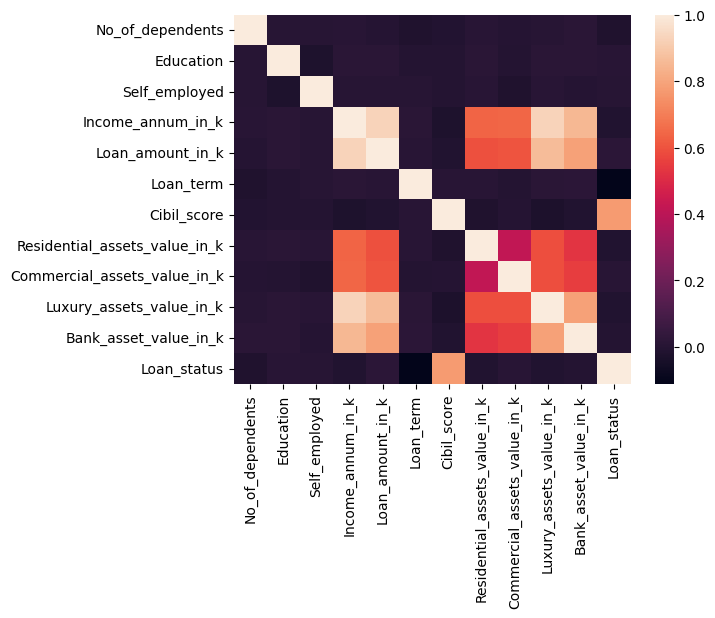

In [23]:
sns.heatmap(clean)

<b>Mapa ciepła dla danych większych bądź równych średniej skali Cibila

<Axes: >

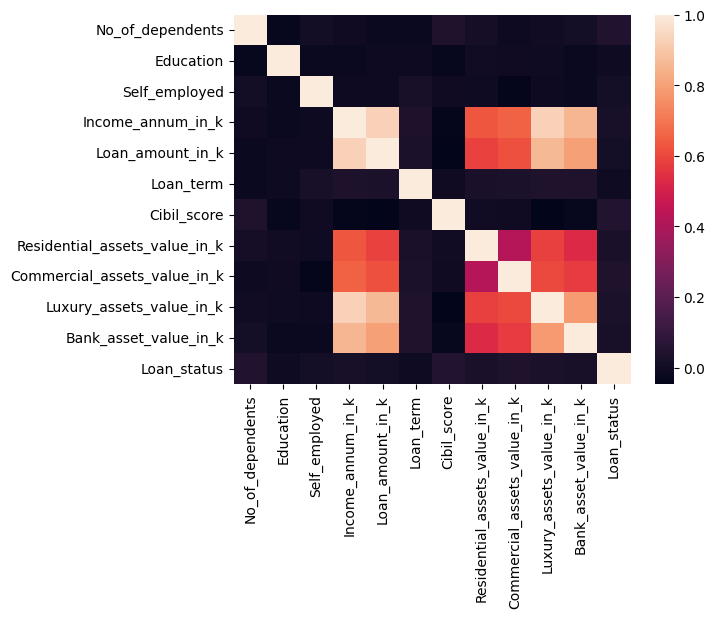

In [24]:
sns.heatmap(high)

<b>Mapa ciepła dla danych mniejszych niż średnia skala Cibila

<Axes: >

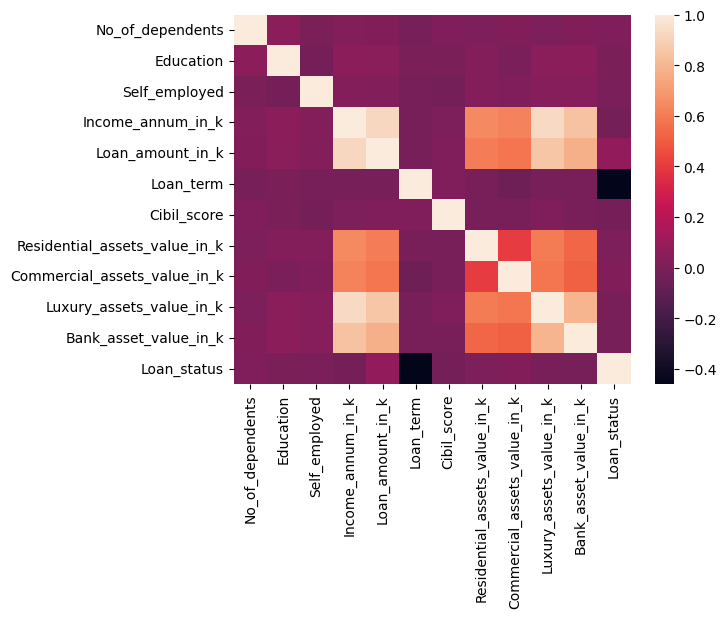

In [25]:
sns.heatmap(low)

<b>Określmy wartości długości terminu spłaty dla jakiej bank zgodzi się na kredyt poniżej skali Cibila 549.

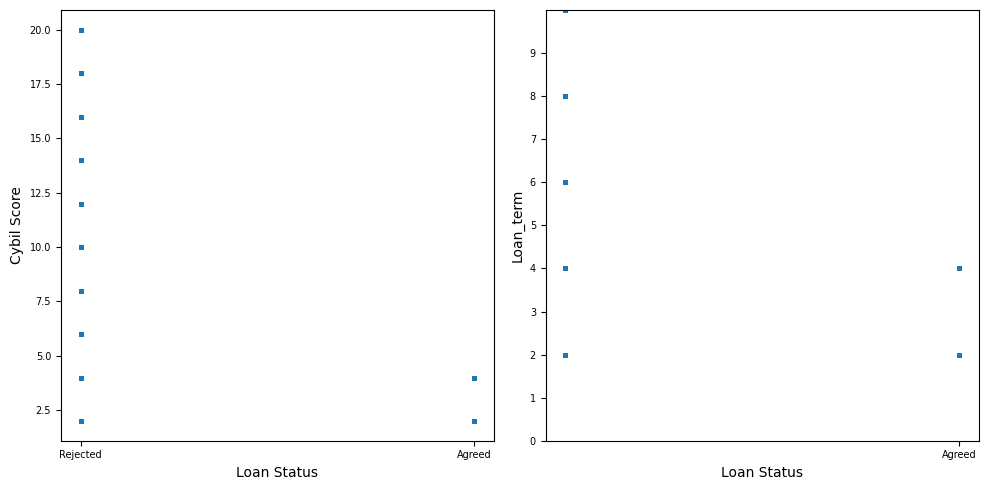

In [26]:
%matplotlib inline

y = df_cib_l['Loan_term']
x = df_cib_l['Loan_status']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(x, y, '.', markersize=5)
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['Rejected', 'Agreed'], fontsize=7)
axs[0].set_ylabel('Cybil Score', fontsize=10)
axs[0].set_xlabel('Loan Status', fontsize=10)
axs[0].tick_params(axis='both', which='both', labelsize=7)

axs[1].plot(x, y, '.', markersize=5)
axs[1].set_xticks([1])
axs[1].set_xticklabels(['Agreed'], fontsize=7)
axs[1].set_ylabel('Loan_term', fontsize=10)
axs[1].set_xlabel('Loan Status', fontsize=10)
axs[1].tick_params(axis='both', which='both', labelsize=7)
axs[1].set_ylim(0, 10)
axs[1].set_yticks(np.arange(0, 10, 1))

plt.tight_layout()
plt.show()

<b>Podzielenie zbioru na dwie części pod względem wartości atrybutu 'Loan_term' dla 'Cibil_score' mniejszego od 549

In [27]:
df_term_h = df_cib_l.loc[df_clean['Loan_term'] > 4]

df_term_l = df_cib_l.loc[df_clean['Loan_term'] <= 4]

<b>Sprawdzenie korelacji pomiędzy atrybutami, gdzie 'Loan_term' jest większy niż 4

In [28]:
df_term_h.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
No_of_dependents,1.000000,0.034456,0.002857,0.021346,0.016301,0.005755,-0.004797,0.011410,0.016951,0.012213,0.016835,NaN
Education,0.034456,1.000000,-0.020051,0.039023,0.038783,0.021834,0.005581,0.017159,-0.010553,0.026701,0.043506,NaN
Self_employed,0.002857,-0.020051,1.000000,0.034490,0.030166,-0.053916,-0.000342,0.035582,0.017839,0.040936,0.033221,NaN
Income_annum_in_k,0.021346,0.039023,0.034490,1.000000,0.923017,-0.019158,-0.003196,0.640167,0.619508,0.929239,0.842735,NaN
Loan_amount_in_k,0.016301,0.038783,0.030166,0.923017,1.000000,-0.023116,0.006094,0.599733,0.572510,0.855288,0.768891,NaN
Loan_term,0.005755,0.021834,-0.053916,-0.019158,-0.023116,1.000000,0.001646,-0.018330,-0.056718,-0.026879,-0.014368,NaN
Cibil_score,-0.004797,0.005581,-0.000342,-0.003196,0.006094,0.001646,1.000000,-0.013043,-0.009270,0.004737,-0.012764,NaN
Residential_assets_value_in_k,0.011410,0.017159,0.035582,0.640167,0.599733,-0.018330,-0.013043,1.000000,0.401825,0.597221,0.505614,NaN
Commercial_assets_value_in_k,0.016951,-0.010553,0.017839,0.619508,0.572510,-0.056718,-0.009270,0.401825,1.000000,0.581571,0.499159,NaN
Luxury_assets_value_in_k,0.012213,0.026701,0.040936,0.929239,0.855288,-0.026879,0.004737,0.597221,0.581571,1.000000,0.792721,NaN


<b><font color='red'>Żaden atrybut nie posiada silnej korelacji z 'Loan_status' ani 'Loan_term'. Wiec nie możemy określić powodu zmiany decyzji banku ani wpływu innych atrybutów na długość spłąty kredytu. Wartość 'Loan_status' jest pusta, co oznacza, że w tym zbiorze wartości 'Loan_status' mają tą samą wartość równą 0. Bank nie zgadza się na kredyty dla osób o średniej ufności przy terminie przekraczającym 4 miesiące.

<b>Sprawdzenie korelacji pomiędzy atrybutami, gdzie 'Loan_term' jest mniejszy bądź równy 4

In [29]:
df_term_l.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status
No_of_dependents,1.000000,0.094713,-0.028353,0.017474,0.014226,0.085926,0.068307,-0.035163,0.003209,-0.017149,0.003346,-0.054596
Education,0.094713,1.000000,-0.043478,0.104016,0.060783,0.009830,-0.027372,0.070291,-0.001416,0.115996,0.099442,-0.059006
Self_employed,-0.028353,-0.043478,1.000000,-0.011147,-0.010545,-0.043976,-0.136064,0.004259,-0.023562,-0.014181,0.018938,0.036232
Income_annum_in_k,0.017474,0.104016,-0.011147,1.000000,0.926785,-0.022346,0.034714,0.666515,0.625084,0.929978,0.849938,-0.080929
Loan_amount_in_k,0.014226,0.060783,-0.010545,0.926785,1.000000,0.019615,0.035589,0.628468,0.616129,0.863602,0.786735,0.212187
Loan_term,0.085926,0.009830,-0.043976,-0.022346,0.019615,1.000000,-0.065942,0.016900,0.018199,0.020496,-0.023979,0.089504
Cibil_score,0.068307,-0.027372,-0.136064,0.034714,0.035589,-0.065942,1.000000,-0.023367,-0.021569,0.018337,-0.011186,-0.040692
Residential_assets_value_in_k,-0.035163,0.070291,0.004259,0.666515,0.628468,0.016900,-0.023367,1.000000,0.411275,0.600932,0.615301,-0.001899
Commercial_assets_value_in_k,0.003209,-0.001416,-0.023562,0.625084,0.616129,0.018199,-0.021569,0.411275,1.000000,0.571862,0.559820,0.002012
Luxury_assets_value_in_k,-0.017149,0.115996,-0.014181,0.929978,0.863602,0.020496,0.018337,0.600932,0.571862,1.000000,0.794828,-0.055383


<b>Atrybut 'Loan_amount_in_k' ma współczynnik korelacji dodatniej 0.21, więc ilość kwota pożyczki ma znaczenie dla kredytobiorców o średnim zaufaniu dla szybkim czasie spłaty kredytu.

<b><font color='red'>Można z tego wywnioskować, że wartość 549 w skali Cibila jest wartością graniczną dla decyzji banku. Skala Cibila jest stosowana w Indiach i przyjmuje wartości od 300 do 900, im większa liczba tym kredytobiorca jest bardziej zaufany. Kredytobiorcy poniżej tej wartości przy czasie spłaty kredytu mniejszym niż 4 miesiące dostają zgodę na zaciągnięcie kredytu od banku.
Z korelacji można również wywnioskować, że pożyczkobiorcy mają swoje aktywa rozlokowane nie tylko w jednym miejscu. Bank nie zgadza się na kredyty dla osób o średniej ufności przy terminie przekraczającym 4 miesiące.

<b>Warto zauważyć, że powstaje nam drzewo decyzyjne.

## Drzewo decyzyjne

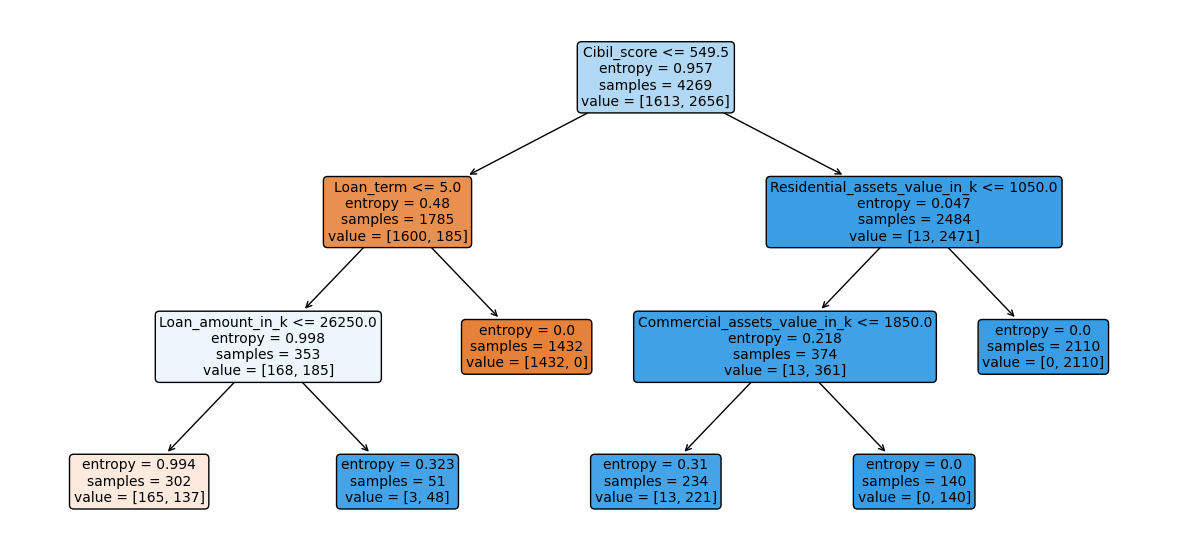

In [30]:
from sklearn import tree
from sklearn.tree import plot_tree

y_target = df_clean['Loan_status'].values

columns = ['No_of_dependents', 'Education', 'Self_employed', 'Income_annum_in_k', 'Loan_amount_in_k', 'Loan_term', 'Cibil_score', 'Residential_assets_value_in_k', 'Commercial_assets_value_in_k', 'Luxury_assets_value_in_k', 'Bank_asset_value_in_k']
X_input = df_clean[list(columns)].values

clf_train = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf_train = clf_train.fit(X_input, y_target)

clf_train.score(X_input,y_target)

plt.figure(figsize=(15,7))
plot_tree(clf_train, feature_names=columns, filled=True, rounded=True, fontsize=10)
plt.show()

<b>Z obrazu drzewa można odczytać, że najwiekszy wpływa mają atrybuty: skala Cibila, ilość miesięcy spłąty kredytu oraz wartość mieszkań pożyczkobiorcy. Jako funkcję podziału użyłem Entropii, a maksymalna ilość poziomów gałęzi w drzewie to 3.

<b>Nasze wnioski wyciągnięte z korelacji potwierdziły się, punkty podziału są dokładniejsze w przypadku drzewa decyzyjnego.

### Sprawdzenie poprawności formuły drzewa

In [31]:
df_predict = df_clean.sample(n=100, random_state=69)

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

predicted_loan_status = clf_train.predict(X_input)

accuracy = accuracy_score(y_target, predicted_loan_status)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_target, predicted_loan_status)
print("Confusion Matrix:")
print(conf_matrix)

precision = precision_score(y_target, predicted_loan_status)
print("Precision:", precision)

recall = recall_score(y_target, predicted_loan_status)
print("Recall:", recall)

Accuracy: 0.9641602248770204
Confusion Matrix:
[[1597   16]
 [ 137 2519]]
Precision: 0.9936883629191321
Recall: 0.9484186746987951


#### Dla 100 losowo pobranych danych z oryginalnego zbioru:

##### Dokładność:
Wynosi 96.4% co oznacza, że model poprawnie radzi sobie z klasyfikacją.
##### Macierz Pomyłek:
Model poprawnie sklasyfikował 1597 przypadków jako negatywne (TN).
Model poprawnie sklasyfikował 2519 przypadków jako pozytywne (TP).
Model popełnił 16 błędów, klasyfikując negatywne przypadki jako pozytywne (FP).
Model popełnił 137 błędów, klasyfikując pozytywne przypadki jako negatywne (FN).
##### Precyzja:
Wynosi 99.3% co oznacza, że model rzadko popełnia błąd, klasyfikując negatywne przypadki jako pozytywne.
##### Czułość:
Wynosi 94.8%, co oznacza, że model dobrze radzi sobie z wykrywaniem pozytywnych przypadków.

<b><font color='red'>Model klasyfikacji osiąga wysoką dokładność wynoszącą 96.4%, niemal wzorową; jednakże pomimo rzadkich błędów w klasyfikacji negatywnych przypadków, wykrywalność pozytywnych przypadków wynosi 94.8%, co sugeruje dobrą, lecz nie idealną skuteczność w ich identyfikacji.

### Predykcja

<b>Podzielmy oryginalny zbiór na dwa podzbiory: testowy i treningowy. Treningowy zbiór stworzy formułę drzewa, a na zbiorze testowym (1100 z 4269 próbek) sprawdzimy precyzję zbioru dla formuły nowego drzewa.

In [32]:
indeksy = np.random.permutation(len(df_clean))
rozmiar_testowy = 1100
indeksy_testowe = indeksy[:rozmiar_testowy]
indeksy_treningowe = indeksy[rozmiar_testowy:]

assert len(set(indeksy_testowe).intersection(set(indeksy_treningowe))) == 0

df_train = df_clean.iloc[indeksy_treningowe]
df_test = df_clean.iloc[indeksy_testowe]

<b>Stworzenie nowej formuły i drzewa

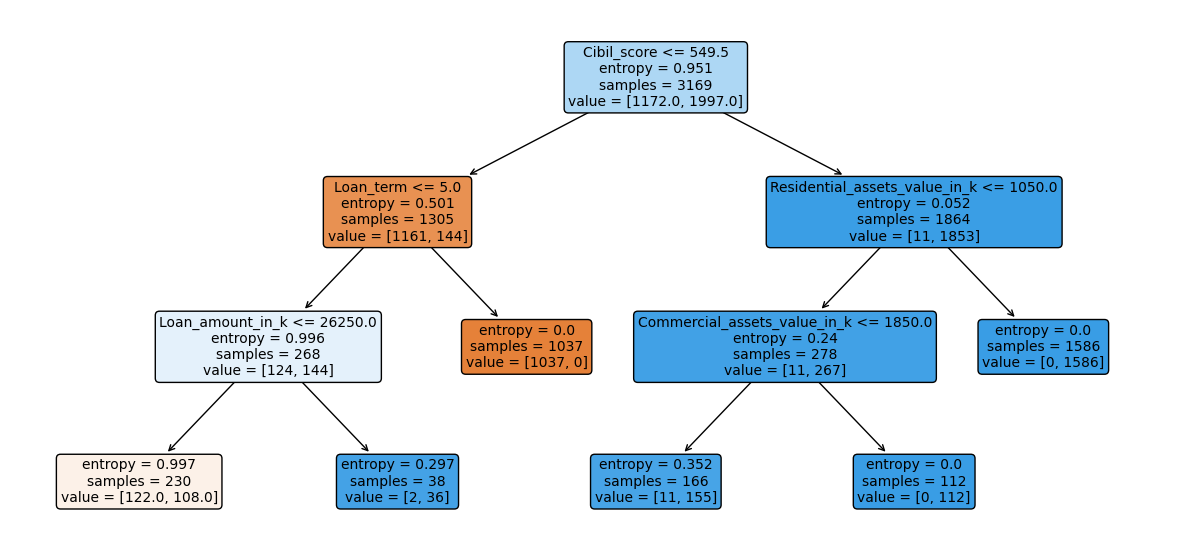

In [33]:
y_target = df_train['Loan_status'].values

columns = ['No_of_dependents', 'Education', 'Self_employed', 'Income_annum_in_k', 'Loan_amount_in_k', 'Loan_term', 'Cibil_score', 'Residential_assets_value_in_k', 'Commercial_assets_value_in_k', 'Luxury_assets_value_in_k', 'Bank_asset_value_in_k']
X_input = df_train[list(columns)].values

clf_train = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf_train = clf_train.fit(X_input, y_target)

clf_train.score(X_input,y_target)

plt.figure(figsize=(15,7))
plot_tree(clf_train, feature_names=columns, filled=True, rounded=True, fontsize=10)
plt.show()

In [34]:
X_test = df_test[list(columns)].values
y_true = df_test['Loan_status'].values

y_pred_test = clf_train.predict(X_test)

accuracy_test = accuracy_score(y_true, y_pred_test)
print("Poprawność predykcji dla zbioru testowego:", accuracy_test)

y_pred_train = clf_train.predict(X_input)

conf_matrix = confusion_matrix(y_target, y_pred_train)
print("Confusion Matrix dla zbioru treningowego:")
print(conf_matrix)

precision = precision_score(y_target, y_pred_train)
print("Precision dla zbioru treningowego:", precision)

recall = recall_score(y_target, y_pred_train)
print("Recall dla zbioru treningowego:", recall)

Poprawność predykcji dla zbioru testowego: 0.9709090909090909
Confusion Matrix dla zbioru treningowego:
[[1159   13]
 [ 108 1889]]
Precision dla zbioru treningowego: 0.9931650893796005
Recall dla zbioru treningowego: 0.9459188783174762


#### Dla 1100 losowo pobranych danych ze zbioru testowego predykcja wykazała:

##### Dokładność:
Wynosi 97% co oznacza, że model poprawnie radzi sobie z klasyfikacją.
##### Macierz Pomyłek:
Model poprawnie sklasyfikował 1159 przypadków jako negatywne (TN).
Model poprawnie sklasyfikował 1889 przypadków jako pozytywne (TP).
Model popełnił 13 błędów, klasyfikując negatywne przypadki jako pozytywne (FP).
Model popełnił 108 błędów, klasyfikując pozytywne przypadki jako negatywne (FN).
##### Precyzja:
Wynosi 99.3% co oznacza, że model rzadko popełnia błąd, klasyfikując negatywne przypadki jako pozytywne.
##### Czułość:
Wynosi 94.5%, co oznacza, że model dobrze radzi sobie z wykrywaniem pozytywnych przypadków.

<b><font color='red'>Model klasyfikacji, przetestowany na 1100 losowo pobranych danych ze zbioru testowego, uzyskał dokładność na poziomie 97%, co świadczy o jego skuteczności w klasyfikacji. Precyzja wynosząca 99.3% sugeruje rzadkie popełnianie błędów w klasyfikacji negatywnych przypadków, natomiast czułość na poziomie 94.5% wskazuje na dobrą zdolność modelu do wykrywania pozytywnych przypadków.

#### Analiza błędów, w celu wykrycia anomalii

In [35]:
df_anomaly = df_train.copy()

df_anomaly['Predicted_Status'] = clf_train.predict(X_input)

misclassified = df_anomaly[df_anomaly['Loan_status'] != df_anomaly['Predicted_Status']]

misclassified.to_csv('./data/loan_approval_misclassified.csv', index=False)

misclassified

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status,Predicted_Status
3369,1,1,1,800,2500,4,409,1300,1000,3100,900,1,0
1067,2,1,1,4200,16800,2,433,3300,0,14100,3700,1,0
4245,5,0,1,6500,23900,2,507,500,10200,15900,8000,1,0
697,0,1,1,6000,23900,4,394,6700,5800,21900,4500,1,0
3721,5,1,1,500,1500,4,476,200,200,1100,700,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3776,1,1,0,7800,23900,4,313,2600,15300,23000,10900,1,0
1544,4,0,0,4300,16500,4,539,10600,6100,9300,2100,1,0
1523,2,1,0,6100,23600,2,476,4600,2900,22500,3800,1,0
1235,4,1,1,8400,25200,2,308,8100,9300,27700,10500,1,0


<b><font color='red'>Po ręcznym przejrzeniu błędnie sklasyfikowanych danych nie można określić, czemu uzyskany wynik jest sprzeczny. Dane te nie mają błędnych wartości.

In [36]:
misclassified.describe()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status,Predicted_Status
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,2.487603,0.537190,0.512397,3806.611570,13169.421488,3.785124,446.983471,5468.595041,3680.165289,11175.206612,3702.479339,0.892562,0.107438
std,1.742200,0.500688,0.501925,2399.851924,8143.635992,2.997795,124.518070,5293.109248,3717.696864,7428.271232,2742.792458,0.310957,0.310957
min,0.000000,0.000000,0.000000,200.000000,500.000000,2.000000,300.000000,-100.000000,0.000000,300.000000,100.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1800.000000,6100.000000,2.000000,350.000000,1100.000000,1000.000000,4600.000000,1600.000000,1.000000,0.000000
50%,3.000000,1.000000,1.000000,3600.000000,12800.000000,4.000000,432.000000,3900.000000,2700.000000,10200.000000,3100.000000,1.000000,0.000000
75%,4.000000,1.000000,1.000000,5500.000000,20000.000000,4.000000,504.000000,7700.000000,5100.000000,16700.000000,5500.000000,1.000000,0.000000
max,5.000000,1.000000,1.000000,9700.000000,31400.000000,20.000000,885.000000,22300.000000,18400.000000,27700.000000,11200.000000,1.000000,1.000000


In [37]:
misclassified.corr()

,No_of_dependents,Education,Self_employed,Income_annum_in_k,Loan_amount_in_k,Loan_term,Cibil_score,Residential_assets_value_in_k,Commercial_assets_value_in_k,Luxury_assets_value_in_k,Bank_asset_value_in_k,Loan_status,Predicted_Status
No_of_dependents,1.000000,0.098454,0.007325,0.065992,0.050633,-0.184006,-0.093116,-0.037274,0.034572,0.050202,0.051016,0.082124,-0.082124
Education,0.098454,1.000000,-0.010140,0.015051,0.018164,0.044232,0.075531,-0.006159,-0.134355,0.037892,0.010552,-0.054409,0.054409
Self_employed,0.007325,-0.010140,1.000000,-0.040886,-0.044045,-0.081290,-0.018264,0.007676,-0.130271,-0.089767,0.001491,-0.071484,0.071484
Income_annum_in_k,0.065992,0.015051,-0.040886,1.000000,0.983644,-0.084822,-0.152751,0.557747,0.680735,0.931133,0.868970,-0.020257,0.020257
Loan_amount_in_k,0.050633,0.018164,-0.044045,0.983644,1.000000,-0.062465,-0.115843,0.559420,0.629481,0.914639,0.845190,-0.010851,0.010851
Loan_term,-0.184006,0.044232,-0.081290,-0.084822,-0.062465,1.000000,0.567483,-0.246002,-0.181784,-0.155169,-0.163311,-0.704379,0.704379
Cibil_score,-0.093116,0.075531,-0.018264,-0.152751,-0.115843,0.567483,1.000000,-0.333338,-0.246863,-0.230237,-0.237075,-0.708126,0.708126
Residential_assets_value_in_k,-0.037274,-0.006159,0.007676,0.557747,0.559420,-0.246002,-0.333338,1.000000,0.448142,0.596264,0.556893,0.313358,-0.313358
Commercial_assets_value_in_k,0.034572,-0.134355,-0.130271,0.680735,0.629481,-0.181784,-0.246863,0.448142,1.000000,0.648249,0.654495,0.073830,-0.073830
Luxury_assets_value_in_k,0.050202,0.037892,-0.089767,0.931133,0.914639,-0.155169,-0.230237,0.596264,0.648249,1.000000,0.850899,0.102017,-0.102017


<b><font color='red'>Z tych obrazów danych nie można określić, czemu uzyskany wynik jest sprzeczny.

### Metoda k-najbliższych sąsiadów

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

X_train, X_test, y_train, y_test = train_test_split(X_input, y_target, test_size=0.2, random_state=42)

k = 13
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)

accuracy_train = knn.score(X_train, y_train)
print("Dokładność modelu KNN dla zbioru treningowego:", accuracy_train)

accuracy_test = knn.score(X_test, y_test)
print("Dokładność modelu KNN dla zbioru testowego:", accuracy_test)

Dokładność modelu KNN dla zbioru treningowego: 0.6690335305719921
Dokładność modelu KNN dla zbioru testowego: 0.5946372239747634


<b><font color='red'>Metoda k-najbliższych sąsiadów klasyfikuje dane o podobnych cecach w sąsiadujące grupy, ilość sąsiadów branych pod uwagę podczas grupowania zależy jest parametrem dobieralnym; w tym przypadku najlepsze efekty daje ilość równa ilości atrybutów w zbiorze danych. Metoda ta nie dała rewelacyjnych rezultatów dla tego zbioru.

## Wnioski

### W ramach problemu: Analiza powodów decyzji banku dotyczącej udzielenia kredytu mieszkaniowego na podstawie danych “Loan-Approval-Prediction-Dataset”. Udało się uzyskać rozwiązanie klasyfikacji o bardzo wysokim stopniu poprawności wynoszacym 97% dla metody drzewa decyzyjnego. Najważniejszymi atrybutami mającymi wpływa na podejmowanie decyzji są: długość spłaty kredytu oraz kwota kredytu. Ponadto w ramach projektu dokonałem predykcji dla ponad 25% losowo wybranych próbek zbioru o skuteczności 96%, co jest rewelacyjnym wynikiem. Nie udało się określić powodu braku 100% skuteczności drzewa decyzyjnego.